#インポート

In [177]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

#シード固定

In [178]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#デバイス・データセット・モデル定義

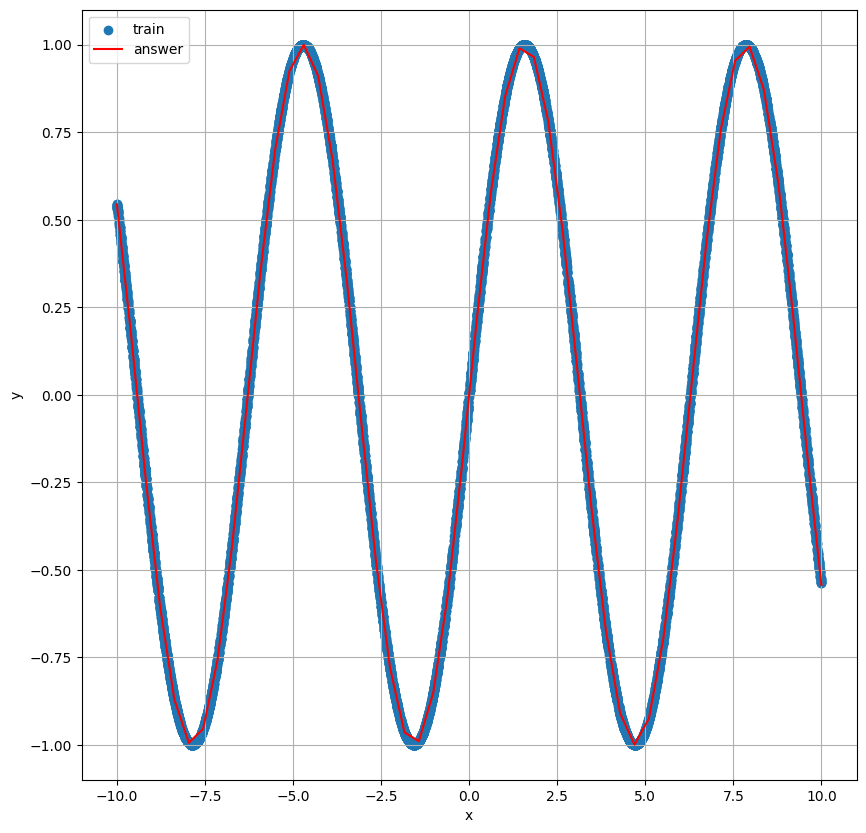

In [179]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def correct(x):
    return np.sin(x)

train_x = np.random.uniform(-10, 10, size = (10000, 1))
train_t = correct(train_x)
test_x = np.random.uniform(-10, 10, size = (10000, 1))
test_t = correct(test_x)

train_x = torch.tensor(train_x, dtype=torch.float32)
train_t = torch.tensor(train_t, dtype=torch.float32)
test_x = torch.tensor(test_x, dtype=torch.float32)
test_t = torch.tensor(test_t, dtype=torch.float32)

fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot()
ax.scatter(train_x, train_t, label = "train")
ax.plot(x:=np.linspace(-10, 10), correct(x), label ="answer", c = "red")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid()

train_dataset = TensorDataset(train_x, train_t)
test_dataset = TensorDataset(test_x, test_t)

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(1, 100)
        self.fc2 = nn.Linear(100, 100)
        self.fc3 = nn.Linear(100, 100)
        self.fc4 = nn.Linear(100, 100)
        self.fc5 = nn.Linear(100, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.tanh(x)
        x = self.fc2(x)
        x = torch.tanh(x)
        x = self.fc3(x)
        x = torch.tanh(x)
        x = self.fc4(x)
        x = torch.tanh(x)
        x = self.fc5(x)
        return x

#学習率・エポック数・バッチサイズ指定、データローダー作る

In [180]:
set_seed(42)
BATCH_SIZE = 512
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)

LEARNING_RATE = 0.001
EPOCHS = 500

#学習ループ

##テストループ

In [181]:
#保留

##SGD

In [182]:
set_seed(42)
model = Model().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = LEARNING_RATE)

SGD_train_loss_history = []
SGD_test_loss_history = []
SGD_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    pb = tqdm(train_loader)
    train_loss = 0
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pb.set_postfix({"loss": loss.item()})

    fg_count += 1
    train_loss /= len(train_loader)

    SGD_x.append(fg_count)
    SGD_train_loss_history.append(train_loss)


    model.eval()
    with torch.no_grad():
        test_loss = 0
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()
            pb.set_postfix({"loss": loss.item()})

    test_loss /= len(test_loader)
    SGD_test_loss_history.append(test_loss)

    print(f"Train Loss: {train_loss:.4f}", "|", f"Test Loss: {test_loss:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 20/20 [00:00<00:00, 260.67it/s, loss=0.485]


Train Loss: 0.4628 | Test Loss: 0.4650
epoch: 2


100%|██████████| 20/20 [00:00<00:00, 382.65it/s, loss=0.485]


Train Loss: 0.4606 | Test Loss: 0.4643
epoch: 3


...

Train Loss: 0.2092 | Test Loss: 0.2174
epoch: 499


100%|██████████| 20/20 [00:00<00:00, 336.94it/s, loss=0.225]


Train Loss: 0.2088 | Test Loss: 0.2173
epoch: 500


100%|██████████| 20/20 [00:00<00:00, 360.56it/s, loss=0.225]

Train Loss: 0.2080 | Test Loss: 0.2170


##SVRG

In [183]:
set_seed(42)
class SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        # full_grad，prev_pを初期化
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['prev_p'] = torch.clone(p) # prev_pの初期値はパラメータ

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            # 平均の誤差にデータ数を掛け総和に変換
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue

                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)

    def culc_prev_grads(self, model, X, T, loss_func):
        # prev_pに切り替え
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_p"]) # パラメータをprev_vに変換

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_vに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                # 補正勾配
                z = state['z']
                prev_grad = state["prev_grad"]
                # 補正勾配を更新
                v = grad - prev_grad + z

                # パラメータを更新
                p.sub_(v, alpha = lr)

        return loss

In [184]:
set_seed(42)
model = Model().to(device)
criterion = nn.MSELoss()
optimizer = SVRG(model.parameters(), lr = LEARNING_RATE)

SVRG_train_loss_history = []
SVRG_test_loss_history = []
SVRG_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss = 0

    optimizer.calc_full_grads(model, train_loader, criterion)
    fg_count += 1

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.culc_prev_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pb.set_postfix({"loss": loss.item()})

    fg_count += 2
    train_loss /= len(train_loader)

    SVRG_x.append(fg_count)
    SVRG_train_loss_history.append(train_loss)


    model.eval()
    with torch.no_grad():
        test_loss = 0
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pb.set_postfix({"loss": loss.item()})

    test_loss /= len(test_loader)

    SVRG_test_loss_history.append(test_loss)

    print(f"Train Loss: {train_loss:.4f}", "|", f"Test Loss: {test_loss:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 20/20 [00:00<00:00, 317.53it/s, loss=0.485]


Train Loss: 0.4609 | Test Loss: 0.4650
epoch: 2


100%|██████████| 20/20 [00:00<00:00, 308.20it/s, loss=0.485]


Train Loss: 0.4609 | Test Loss: 0.4643
epoch: 3


...

Train Loss: 0.4218 | Test Loss: 0.4261
epoch: 166


100%|██████████| 20/20 [00:00<00:00, 348.22it/s, loss=0.452]


Train Loss: 0.4214 | Test Loss: 0.4257
epoch: 167


100%|██████████| 20/20 [00:00<00:00, 322.85it/s, loss=0.452]

Train Loss: 0.4208 | Test Loss: 0.4254


##No Full Grad SVRG

In [185]:
set_seed(42)
class NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["prev_a"] = torch.zeros_like(p) # prev_aを'a'のクローンとして初期化

                state["prev_a"].copy_(state["a"])
                state["a"].zero_()
                state['prev_p'] = torch.clone(p).detach() # prev_pの初期値はパラメータ
                state["t"] = 0

    def culc_prev_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_p"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_pに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                # 補正勾配
                a = state['a']
                prev_a = state["prev_a"]
                prev_grad = state["prev_grad"]
                t = state["t"]

                # 平均勾配を更新
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                # 補正勾配を更新
                v = grad - prev_grad + prev_a

                # パラメータを更新
                p.sub_(v, alpha = lr)
                state["t"] += 1

        return loss

In [186]:
set_seed(42)
model = Model().to(device)
criterion = nn.MSELoss()
optimizer = NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

NFG_SVRG_train_loss_history = []
NFG_SVRG_test_loss_history = []
NFG_SVRG_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss = 0

    optimizer.init_epoch()

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.culc_prev_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pb.set_postfix({"loss": loss.item()})

    fg_count += 2
    train_loss /= len(train_loader)

    NFG_SVRG_x.append(fg_count)
    NFG_SVRG_train_loss_history.append(train_loss)


    model.eval()
    with torch.no_grad():
        test_loss = 0
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pb.set_postfix({"loss": loss.item()})

    test_loss /= len(test_loader)

    NFG_SVRG_test_loss_history.append(test_loss)

    print(f"Train Loss: {train_loss:.4f}", "|", f"Test Loss: {test_loss:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 20/20 [00:00<00:00, 347.39it/s, loss=0.486]


Train Loss: 0.4633 | Test Loss: 0.4659
epoch: 2


100%|██████████| 20/20 [00:00<00:00, 350.28it/s, loss=0.485]


Train Loss: 0.4615 | Test Loss: 0.4650
epoch: 3


...

Train Loss: 0.3864 | Test Loss: 0.3910
epoch: 249


100%|██████████| 20/20 [00:00<00:00, 332.18it/s, loss=0.418]


Train Loss: 0.3855 | Test Loss: 0.3905
epoch: 250


100%|██████████| 20/20 [00:00<00:00, 314.17it/s, loss=0.418]

Train Loss: 0.3848 | Test Loss: 0.3899


##Primal No Full Grad SVRG

In [187]:
set_seed(42)
class Primal_NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["prev_a"] = torch.zeros_like(p)
                    state["z"] = torch.clone(p.detach())
                    state["prev_z"] = torch.clone(p.detach())

                state["prev_a"].copy_(state["a"])
                state["a"].zero_()
                state['prev_z'].copy_(state["z"])
                state["z"].zero_()
                state["t"] = 0

    def culc_prev_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_z"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_pに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                a = state['a']
                prev_a = state["prev_a"]
                prev_grad = state["prev_grad"]
                z = state["z"]
                t = state["t"]

                # 平均勾配を更新
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))
                # 補正勾配を更新
                v = grad - prev_grad + prev_a
                # パラメータを更新
                p.sub_(v, alpha = lr)
                # 平均パラメーターを更新
                z.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))
                state["t"] += 1

        return loss

In [188]:
set_seed(42)
model = Model().to(device)
criterion = nn.MSELoss()
optimizer = Primal_NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

Primal_NFG_SVRG_train_loss_history = []
Primal_NFG_SVRG_test_loss_history = []
Primal_NFG_SVRG_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss = 0

    optimizer.init_epoch()

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.culc_prev_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pb.set_postfix({"loss": loss.item()})

    fg_count += 2
    train_loss /= len(train_loader)

    Primal_NFG_SVRG_x.append(fg_count)
    Primal_NFG_SVRG_train_loss_history.append(train_loss)


    model.eval()
    with torch.no_grad():
        pb = tqdm(test_loader)
        test_loss = 0

        backup = []
        with torch.no_grad():
            for group in optimizer.param_groups:
                for p in group['params']:
                    state = optimizer.state[p]
                    backup.append(p.clone())
                    p.copy_(state["z"])

        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pb.set_postfix({"loss": loss.item()})

        with torch.no_grad():
            i = 0
            for group in optimizer.param_groups:
                for p in group['params']:
                    p.copy_(backup[i])
                    i += 1

    test_loss /= len(test_loader)

    Primal_NFG_SVRG_test_loss_history.append(test_loss)

    print(f"Train Loss: {train_loss:.4f}", "|", f"Test Loss: {test_loss:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 20/20 [00:00<00:00, 273.42it/s, loss=0.486]


Train Loss: 0.4633 | Test Loss: 0.4659
epoch: 2


100%|██████████| 20/20 [00:00<00:00, 298.51it/s, loss=0.486]


Train Loss: 0.4615 | Test Loss: 0.4654
epoch: 3


...

Train Loss: 0.3860 | Test Loss: 0.3909
epoch: 249


100%|██████████| 20/20 [00:00<00:00, 390.70it/s, loss=0.418]


Train Loss: 0.3851 | Test Loss: 0.3904
epoch: 250


100%|██████████| 20/20 [00:00<00:00, 333.86it/s, loss=0.418]

Train Loss: 0.3844 | Test Loss: 0.3898


#結果

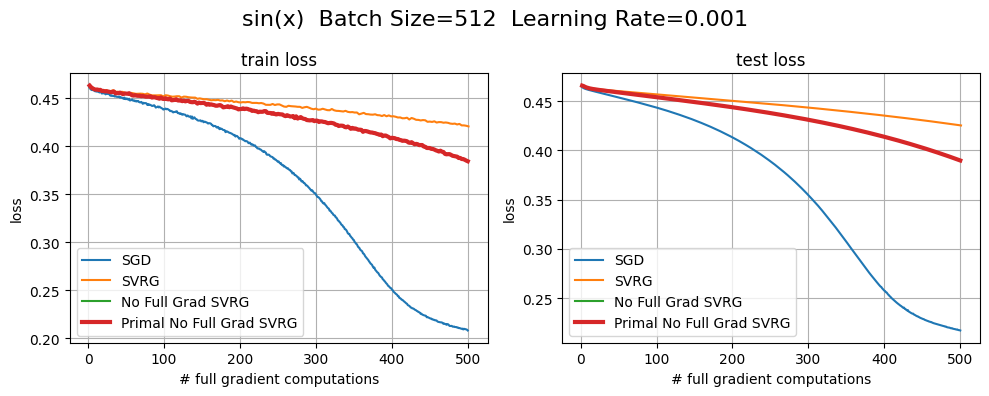

In [189]:
fig = plt.figure(figsize = (10, 4))
fig.suptitle(f"sin(x)  Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)
ax = fig.add_subplot(1, 2, 1)
ax.plot(SGD_x, SGD_train_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_loss_history, label = "No Full Grad SVRG")
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_train_loss_history, label = "Primal No Full Grad SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.plot(SGD_x, SGD_test_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_test_loss_history, label = "Primal No Full Grad SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

In [190]:
import json
# write
with open("result.json", "w") as f:
    json.dump({
        "sin(x)_model3_0.01_64_SGD_train_loss",
        "sin(x)_model3_0.01_64_SGD_train_acc",
        "sin(x)_model3_0.01_64_SVRG_train_loss",
        "sin(x)_model3_0.01_64_SVRG_train_acc",
        "sin(x)_model3_0.01_64_NFG_SVRG_train_loss",
        "sin(x)_model3_0.01_64_NFG_SVRG_train_acc",

    }, f, indent=4)

# read
with open("result.json", 'r') as f:
    results = json.load(f)
results['train_acc']

TypeError: Object of type set is not JSON serializable